In [4]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from scipy import sparse
 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.model_selection import cross_val_score
 
warnings.filterwarnings('ignore')
print("Imports done.")

Imports done.


In [5]:
with open('../models/y_train.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open('../models/y_test.pkl', 'rb') as f:
    y_test = pickle.load(f)
with open('../models/X_train_tfidf.pkl', 'rb') as f:
    X_train_tfidf = pickle.load(f)
with open('../models/X_test_tfidf.pkl', 'rb') as f:
    X_test_tfidf = pickle.load(f)
with open('../models/X_train_final.pkl', 'rb') as f:
    X_train_hybrid = pickle.load(f)
with open('../models/X_test_final.pkl', 'rb') as f:
    X_test_hybrid = pickle.load(f)
 
print(f"y_train      : {y_train.shape}")
print(f"X_train_tfidf: {X_train_tfidf.shape}")
print(f"X_train_hybrid: {X_train_hybrid.shape}")
 
print(f"\nTrain + Test = {len(y_train) + len(y_test)} rows (should be 57689)")


y_train      : (46151,)
X_train_tfidf: (46151, 15000)
X_train_hybrid: (46151, 15010)

Train + Test = 57689 rows (should be 57689)


In [6]:
def clean_sparse(X):
    if sparse.issparse(X):
        X = X.copy()
        X.data = np.nan_to_num(X.data)
        return X
    return np.nan_to_num(X)
 
X_train_hybrid = clean_sparse(X_train_hybrid)
X_test_hybrid  = clean_sparse(X_test_hybrid)
print("NaN values cleaned from hybrid matrices.")

NaN values cleaned from hybrid matrices.


In [7]:

df_meta = pd.read_csv('../data/labeled_data.csv')
 
train_meta = df_meta.loc[y_train.index]   
sample_weights = train_meta['source'].map({'kaggle': 1.0, 'liar': 1.2}).values

 
print(f"Sample weights shape: {sample_weights.shape}")
print(f"Unique weights: {np.unique(sample_weights)}")
 


Sample weights shape: (46151,)
Unique weights: [1.  1.2]


In [8]:

start = time.time()
 
lr = LogisticRegression(C=2.0, max_iter=2000, solver='saga', random_state=42, n_jobs=-1)

lr.fit(X_train_tfidf, y_train, sample_weight=sample_weights)
lr_preds = lr.predict(X_test_tfidf)
lr_proba = lr.predict_proba(X_test_tfidf)[:, 1]
 
lr_acc = accuracy_score(y_test, lr_preds)
lr_auc = roc_auc_score(y_test, lr_proba)
lr_time = time.time() - start
 
print(f"LR  | Acc: {lr_acc:.4f} | AUC: {lr_auc:.4f} | Time: {lr_time:.1f}s")
 


LR  | Acc: 0.9086 | AUC: 0.9782 | Time: 1.2s


In [9]:

start = time.time()
 
nb = MultinomialNB(alpha=0.5)
nb.fit(X_train_tfidf, y_train, sample_weight=sample_weights)
nb_preds = nb.predict(X_test_tfidf)
nb_proba = nb.predict_proba(X_test_tfidf)[:, 1]
 
nb_acc = accuracy_score(y_test, nb_preds)
nb_auc = roc_auc_score(y_test, nb_proba)
nb_time = time.time() - start
 
print(f"NB  | Acc: {nb_acc:.4f} | AUC: {nb_auc:.4f} | Time: {nb_time:.1f}s")


NB  | Acc: 0.8762 | AUC: 0.9620 | Time: 0.0s


In [10]:
start = time.time()
 
rf = RandomForestClassifier(
    n_estimators=300,
    max_features='log2',      
    min_samples_leaf=1,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train_hybrid, y_train, sample_weight=sample_weights)
rf_preds = rf.predict(X_test_hybrid)
rf_proba = rf.predict_proba(X_test_hybrid)[:, 1]
 
rf_acc = accuracy_score(y_test, rf_preds)
rf_auc = roc_auc_score(y_test, rf_proba)
rf_time = time.time() - start
 
print(f"RF  | Acc: {rf_acc:.4f} | AUC: {rf_auc:.4f} | Time: {rf_time:.1f}s")
 


RF  | Acc: 0.9122 | AUC: 0.9774 | Time: 38.8s


In [11]:
from sklearn.preprocessing import MaxAbsScaler
 
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train_tfidf)
X_test_scaled  = scaler.transform(X_test_tfidf)
 
start = time.time()
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    solver='adam',
    alpha=0.001,               #
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,       
    random_state=42
)
mlp.fit(X_train_scaled, y_train) 
mlp_preds = mlp.predict(X_test_scaled)
mlp_proba = mlp.predict_proba(X_test_scaled)[:, 1]
 
mlp_acc = accuracy_score(y_test, mlp_preds)
mlp_auc = roc_auc_score(y_test, mlp_proba)
mlp_time = time.time() - start
 
print(f"MLP | Acc: {mlp_acc:.4f} | AUC: {mlp_auc:.4f} | Time: {mlp_time:.1f}s")
 


MLP | Acc: 0.9097 | AUC: 0.9799 | Time: 311.4s


In [12]:
from sklearn.ensemble import StackingClassifier

start = time.time()

lr_ens = LogisticRegression(C=2.0, max_iter=2000, solver='saga',
                             random_state=42, n_jobs=-1)
nb_ens = MultinomialNB(alpha=0.5)
rf_ens = RandomForestClassifier(n_estimators=300, max_features='log2',
                                 min_samples_leaf=1, n_jobs=-1, random_state=42)

ensemble = StackingClassifier(
    estimators=[('lr', lr_ens), ('nb', nb_ens), ('rf', rf_ens)],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, solver='saga'),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=-1
)
ensemble.fit(X_train_tfidf, y_train)   
ens_preds = ensemble.predict(X_test_tfidf)
ens_proba = ensemble.predict_proba(X_test_tfidf)[:, 1]

ens_acc = accuracy_score(y_test, ens_preds)
ens_auc = roc_auc_score(y_test, ens_proba)
ens_time = time.time() - start

print(f"ENS | Acc: {ens_acc:.4f} | AUC: {ens_auc:.4f} | Time: {ens_time:.1f}s")




ENS | Acc: 0.9087 | AUC: 0.9796 | Time: 279.4s



=== Model Performance Summary ===
                     Accuracy     AUC
Random Forest          0.9122  0.9774
MLP Neural Net         0.9097  0.9799
Voting Ensemble        0.9087  0.9796
Logistic Regression    0.9086  0.9782
Naive Bayes            0.8762  0.9620


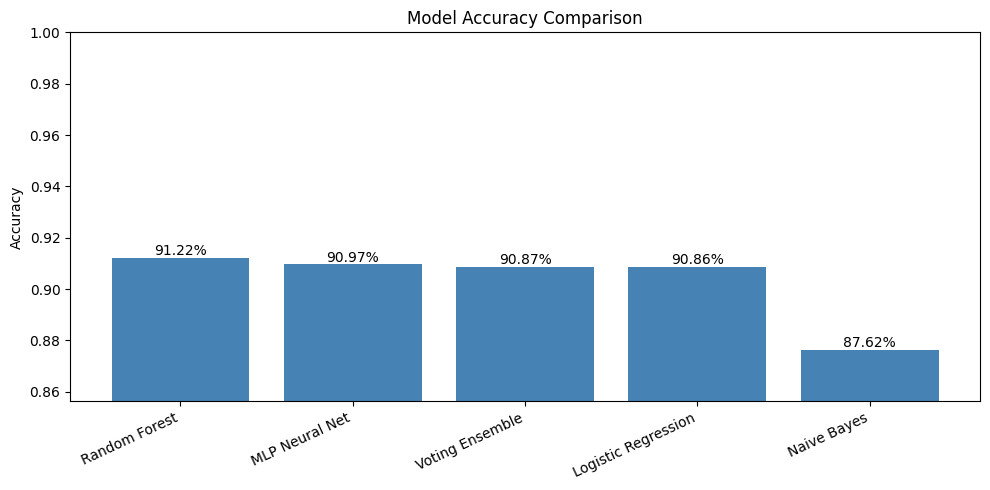

In [13]:
results = {
    'Logistic Regression': {'acc': lr_acc,  'auc': lr_auc,  'preds': lr_preds,  'proba': lr_proba},
    'Naive Bayes':          {'acc': nb_acc,  'auc': nb_auc,  'preds': nb_preds,  'proba': nb_proba},
    'Random Forest':        {'acc': rf_acc,  'auc': rf_auc,  'preds': rf_preds,  'proba': rf_proba},
    'MLP Neural Net':       {'acc': mlp_acc, 'auc': mlp_auc, 'preds': mlp_preds, 'proba': mlp_proba},
    'Voting Ensemble':      {'acc': ens_acc, 'auc': ens_auc, 'preds': ens_preds, 'proba': ens_proba},
}
 
summary_df = pd.DataFrame(
    {name: {'Accuracy': v['acc'], 'AUC': v['auc']} for name, v in results.items()}
).T.sort_values('Accuracy', ascending=False)
 
print("\n=== Model Performance Summary ===")
print(summary_df.round(4).to_string())
 
# Bar chart
plt.figure(figsize=(10, 5))
bars = plt.bar(summary_df.index, summary_df['Accuracy'], color='steelblue')
min_acc = summary_df['Accuracy'].min()
plt.ylim(min_acc - 0.02, 1.0)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=25, ha='right')
for bar, val in zip(bars, summary_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val*100:.2f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()
 


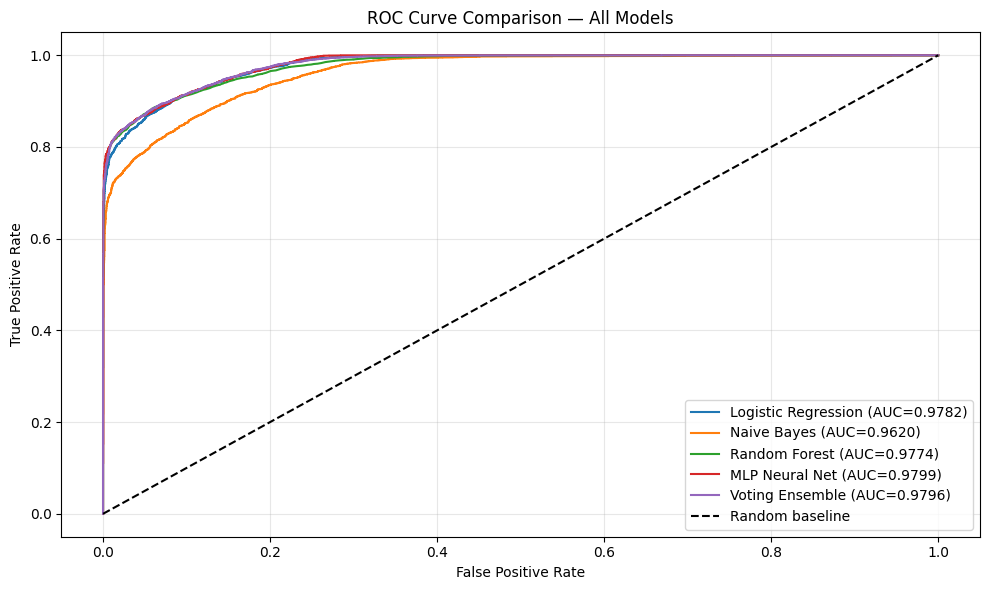

In [14]:
eval_map = {
    'Logistic Regression': (X_test_tfidf, lr_proba),
    'Naive Bayes':          (X_test_tfidf, nb_proba),
    'Random Forest':        (X_test_hybrid, rf_proba),
    'MLP Neural Net':       (X_test_scaled, mlp_proba),
    'Voting Ensemble':      (X_test_tfidf, ens_proba),
}
 
plt.figure(figsize=(10, 6))
for name, (_, proba) in eval_map.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = results[name]['auc']
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})")
 
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
 


=== Best Model: Random Forest ===
              precision    recall  f1-score   support

        Real       0.89      0.94      0.91      5710
        Fake       0.94      0.89      0.91      5828

    accuracy                           0.91     11538
   macro avg       0.91      0.91      0.91     11538
weighted avg       0.91      0.91      0.91     11538



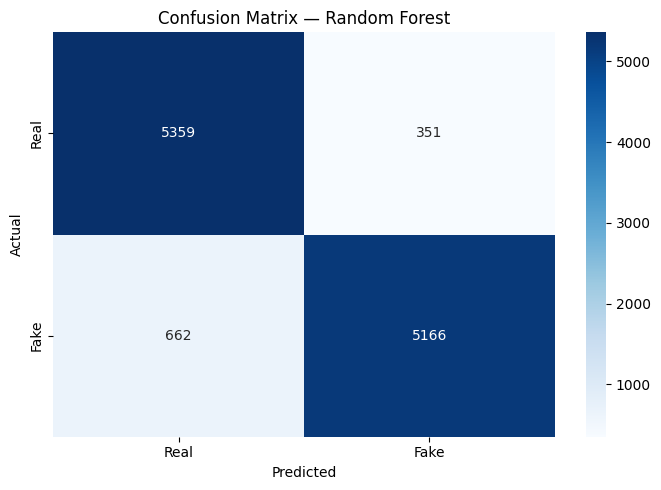

In [15]:
best_name = summary_df.index[0]
best = results[best_name]
best_preds = best['preds']
 
print(f"=== Best Model: {best_name} ===")
print(classification_report(y_test, best_preds, target_names=['Real', 'Fake']))
 
cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real', 'Fake'],
            yticklabels=['Real', 'Fake'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
 


In [16]:
with open('../models/lr_model.pkl', 'wb') as f:
    pickle.dump(lr, f)
with open('../models/nb_model.pkl', 'wb') as f:
    pickle.dump(nb, f)
with open('../models/rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
with open('../models/mlp_model.pkl', 'wb') as f:
    pickle.dump(mlp, f)
with open('../models/ensemble_model.pkl', 'wb') as f:
    pickle.dump(ensemble, f)
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
 
with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(results[best_name], f)  
 
import pickle
best_sklearn_model = ensemble if best_name == 'Voting Ensemble' else \
                     lr if best_name == 'Logistic Regression' else \
                     rf if best_name == 'Random Forest' else \
                     mlp if best_name == 'MLP Neural Net' else nb
 
with open('../models/best_model_tfidf.pkl', 'wb') as f:
    pickle.dump(best_sklearn_model, f)
 
print(f"All models saved.")
print(f"Best model '{best_name}' saved as best_model_tfidf.pkl")
print(f"\nNote for NB4: Best model uses {'tfidf' if best_name != 'Random Forest' else 'hybrid'} features.")
 


All models saved.
Best model 'Random Forest' saved as best_model_tfidf.pkl

Note for NB4: Best model uses hybrid features.
